In [59]:
from upconversion_models import AndersonModel, cmap
from upconversion_models.jablonski_patch import (
    Simulator,
    EmissionTransform,
    LineEnergyPost,
    SteadyState,
)
from poincare import solvers
from pint import get_application_registry
import numpy as np
from matplotlib import pyplot as plt

u = get_application_registry()

In [60]:
system = AndersonModel()
sim = (
    Simulator(system)
    .with_transform(EmissionTransform("emission"), append=True)
    .with_solver(solvers.LSODA(rtol=1e-10, atol=1e-10))
    .with_post(LineEnergyPost())
)
steady = SteadyState()

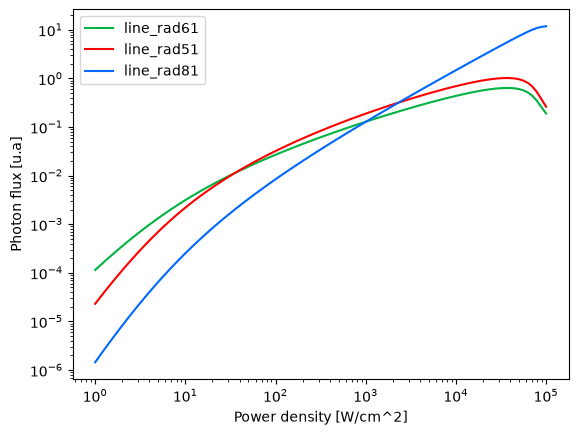

In [61]:
energy_flux_values = np.logspace(0, 5, 100) * u.W / u.cm**2
res = steady.sweep(sim, variable=AndersonModel.energy_flux, values=energy_flux_values)

res.to_dataframe()[["line_rad61", "line_rad51", "line_rad81"]].plot(
    color=[cmap["g"], cmap["r"], cmap["b"]]
)

plt.xlabel("Power density [W/cm^2]")
plt.ylabel("Photon flux [u.a]")

plt.xscale("log")
plt.yscale("log")
plt.show()

In [62]:
from upconversion_models.jablonski_patch import piecewise
from poincare import solvers

sim = (
    Simulator(system)
    .with_transform(EmissionTransform(kind="emission"), append=True)
    .with_solver(solvers.LSODA(rtol=1e-14, atol=1e-14))
)
pulse_density = 30e-3 * u.J / u.cm**2
pulse_width = 1e-5 * u.s
pulse_height = pulse_density / pulse_width

pulse = {
    0 * u.s: {system.energy_flux: pulse_height},
    pulse_width: {system.energy_flux: 0 * u.W / u.cm**2},
}

res = (
    piecewise(sim, events=pulse, save_at=np.linspace(0, 2e-3, 1000) * u.s)
)

res = res.pint.dequantify()
res

/Users/ramirohar/Documents/tesis/upconversion_models/.pixi/envs/default/lib/python3.13/site-packages/scipy_events/_core.py:72: UserWarning: At least one element of `rtol` is too small. Setting `rtol = np.maximum(rtol, 2.220446049250313e-14)`.
  solver = self.solver_cls(*args, **kwargs)


<xarray.Dataset> Size: 208kB
Dimensions:     (time: 1001)
Coordinates:
  * time        (time) float64 8kB 0.0 2.002e-06 4.004e-06 ... 0.001998 0.002
Data variables: (12/25)
    line_rad    (time) float64 8kB 0.0 0.016 0.02883 ... 0.009924 0.009913
    line_rad81  (time) float64 8kB 0.0 4.168e-10 ... 2.753e-05 2.743e-05
    line_rad82  (time) float64 8kB 0.0 4.376e-10 3.88e-08 ... 2.89e-05 2.88e-05
    line_rad83  (time) float64 8kB 0.0 1.459e-10 1.293e-08 ... 9.634e-06 9.6e-06
    line_rad85  (time) float64 8kB 0.0 4.168e-11 ... 2.753e-06 2.743e-06
    line_rad61  (time) float64 8kB 0.0 1.426e-06 ... 0.0007389 0.0007372
    ...          ...
    Er6         (time) float64 8kB 0.0 1.349e-09 ... 6.99e-07 6.974e-07
    Er7         (time) float64 8kB 0.0 2.845e-09 ... 6.855e-09 6.838e-09
    Er8         (time) float64 8kB 0.0 4.472e-13 ... 2.954e-08 2.943e-08
    Er9         (time) float64 8kB 0.0 8.735e-13 ... 6.089e-10 6.068e-10
    Yb1         (time) float64 8kB 0.171 0.171 0.1709 ... 0.171 0.171 0.171
    Yb2         (time) float64 8kB 0.0 4.072e-05 ... 2.525e-05 2.522e-05

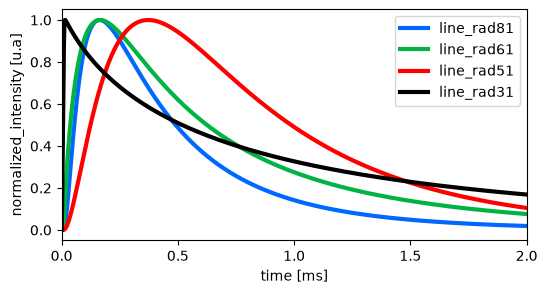

In [63]:
df = res.to_dataframe()[["line_rad81","line_rad61","line_rad51","line_rad31"]]

df.index = (df.index) * 1e3
df.div(df.max()).plot(
    color=[cmap["b"], cmap["g"], cmap["r"], "black"], figsize=(6, 3), lw=3
)
plt.ylabel("normalized_intensity [u.a]")
plt.xlabel('time [ms]')

plt.xlim(0,2)
plt.xticks([0,0.5,1,1.5,2])

plt.show()

/Users/ramirohar/Documents/tesis/upconversion_models/.pixi/envs/default/lib/python3.13/site-packages/scipy_events/_core.py:72: UserWarning: At least one element of `rtol` is too small. Setting `rtol = np.maximum(rtol, 2.220446049250313e-14)`.
  solver = self.solver_cls(*args, **kwargs)


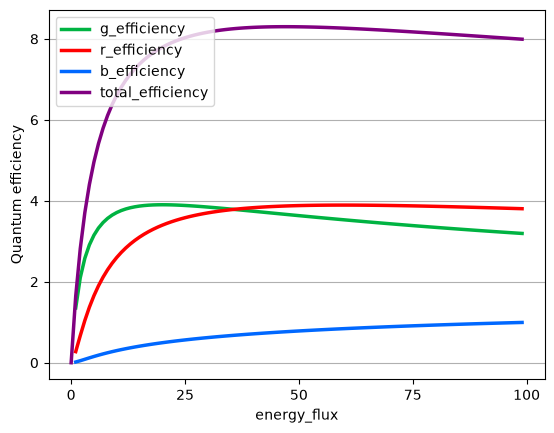

In [64]:
from jablonski.util import emission_transitions
import xarray as xr

lines = {
    f"line_{transition}": transition
    for transition in emission_transitions(system, kind="fluorescence")
}

transform = {k: v.radiative_decay.rate_law for k, v in lines.items()} | {
    "abs": system.abs.absorption.rate_law
}

sim2 = sim.with_transform(transform, append=True)
steady = SteadyState()

values = np.arange(0, 100, 1) * u.W / u.cm**2


res = steady.sweep(sim2, variable=AndersonModel.energy_flux, values=values)

df = res.to_dataframe()
df["green"] = df["line_rad61"]
df["red"] = df["line_rad51"]
df["blue"] = df["line_rad81"]

df["g_efficiency"] = df["green"] / df["abs"] * 100
df["r_efficiency"] = df["red"] / df["abs"] * 100
df["b_efficiency"] = df["blue"] / df["abs"] * 100
df["total_efficiency"] = df[["g_efficiency", "r_efficiency", "b_efficiency"]].sum(
    axis=1
)

df[["g_efficiency", "r_efficiency", "b_efficiency", "total_efficiency"]].plot(
    color=[cmap["g"], cmap["r"], cmap["b"], "purple"], lw=2.5
)


plt.xticks(np.arange(0, 101, 25))
plt.ylabel("Quantum efficiency")
plt.grid(axis="y")

/Users/ramirohar/Documents/tesis/upconversion_models/.pixi/envs/default/lib/python3.13/site-packages/scipy_events/_core.py:72: UserWarning: At least one element of `rtol` is too small. Setting `rtol = np.maximum(rtol, 2.220446049250313e-14)`.
  solver = self.solver_cls(*args, **kwargs)
/Users/ramirohar/Documents/tesis/upconversion_models/.pixi/envs/default/lib/python3.13/site-packages/matplotlib/cbook.py:1407: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  return np.asanyarray(x, float)


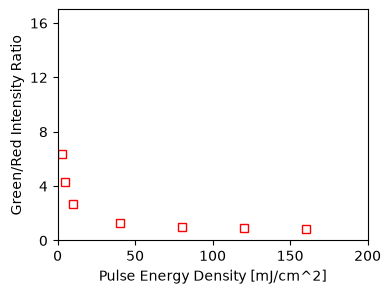

In [65]:
from upconversion_models.jablonski_patch import PulsedExcitation


ratios = []
pulse_densities = (
    np.array([3e-3, 5e-3, 10e-3, 40e-3, 80e-3, 120e-3, 160e-3])
    * u.J
    / u.cm**2
)
for pulse_density in pulse_densities:
    pulse_width = .7e-7 * u.s

    pulse = PulsedExcitation(
        pulse_width=pulse_width,
        pulse_height=pulse_density / pulse_width,
        pump="energy_flux",
    )

    save_at = np.linspace(0, 5e-3, 100000) * u.s
    df = (
        pulse.solve(sim, save_at=save_at)
        .pint.dequantify()
        .to_dataframe()[["line_rad61", "line_rad51"]]
        .sum()
    )

    ratio = df["line_rad61"] * 655 / df["line_rad51"] / 541

    ratios.append(ratio)

plt.figure(figsize=(4,3))

plt.plot(pulse_densities * 1e3, ratios, "s", color="red", mfc="none")
plt.xlim(0, 200)
plt.xticks([0, 50, 100, 150, 200])
plt.ylim(0, 17)
plt.yticks([0, 4, 8, 12, 16])
plt.xlabel('Pulse Energy Density [mJ/cm^2]')
plt.ylabel('Green/Red Intensity Ratio')

plt.show()